In [ ]:
#1

In [74]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [53]:
image_gray = cv2.imread('sar_1_gray.jpg')

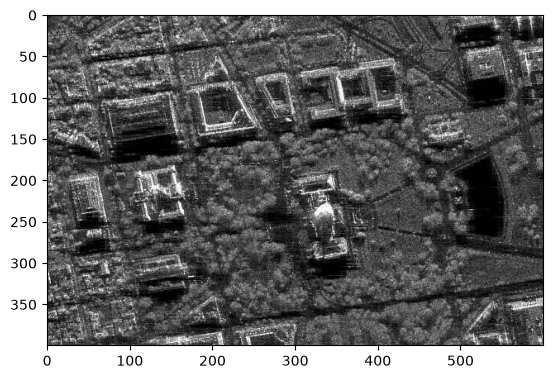

In [54]:
plt.imshow(image_gray)

In [ ]:
#2

In [55]:
histSize = 256
histRange = (0, 256)
accumulate = False

image_gray_hist = cv2.calcHist([image_gray], [0], None, [histSize], histRange, accumulate=accumulate)

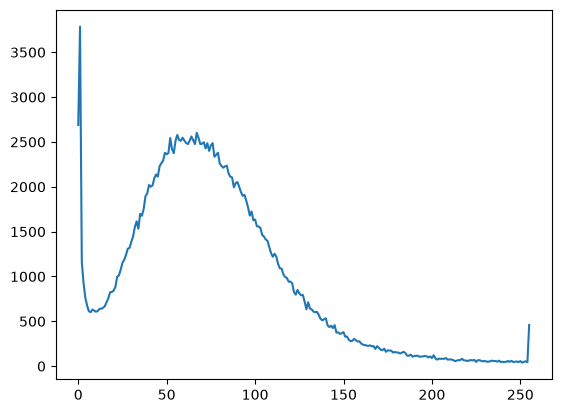

In [56]:
plt.plot(image_gray_hist)

In [ ]:
#3

In [57]:
def gamma_correction(image, gamma):
    table = np.array([((i / 255.0) ** gamma) * 255 for i in np.arange(0, 256)]).astype("uint8")
    return cv2.LUT(image, table)

In [58]:
image_gray_gamma = gamma_correction(image_gray, gamma=0.5)

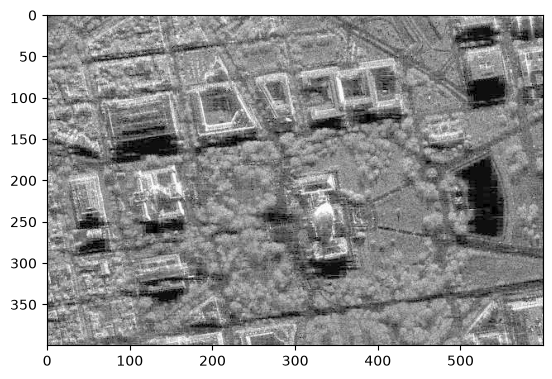

In [63]:
plt.imshow(image_gray_gamma)

In [ ]:
#4

In [70]:
from skimage.metrics import structural_similarity, mean_squared_error

(ssim, diff) = structural_similarity(image_gray, image_gray_gamma, full=True, channel_axis=2)
diff = (diff * 255).astype("uint8")
print(f"SSIM: {ssim}")

SSIM: 0.7875008686792752


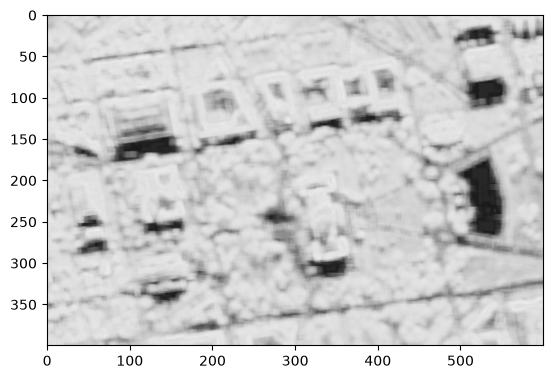

In [68]:
plt.imshow(diff)

In [72]:
mse = mean_squared_error(image_gray, image_gray_gamma)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

MSE: 3250.43
RMSE: 57.01


In [90]:
#5

In [91]:
eq_gray = cv2.equalizeHist(image_gray)

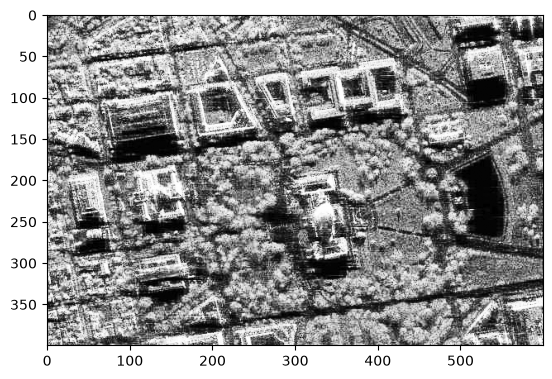

In [92]:
plt.imshow(eq_gray, cmap="gray")

In [101]:
def stat_corrected(target, source):
    E_t = target.mean()
    D_t = target.std()
    E_s = source.mean()
    D_s = source.std()

    С_t = target.astype(np.float32)

    C_t_new = E_s + (С_t - E_t) * (D_s / (D_t + 1e-5))
    
    stat_corrected = np.clip(C_t_new, 0, 255).astype(np.uint8)

    return stat_corrected;

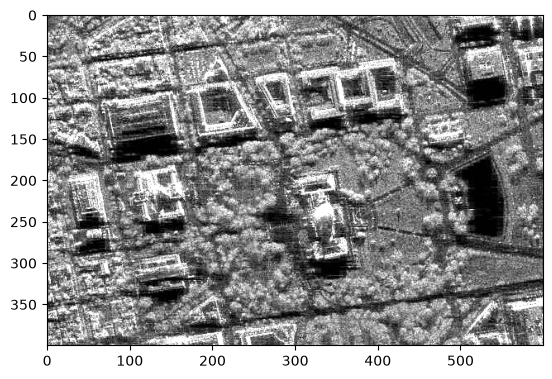

In [102]:
image_stat_corrected = stat_corrected(image_gray, eq_gray)
plt.imshow(image_stat_corrected, cmap="gray")

In [104]:
ssim= structural_similarity(eq_gray, image_stat_corrected, full=False)
print(f"SSIM: {ssim}")

SSIM: 0.9500070636130857


In [115]:
#6

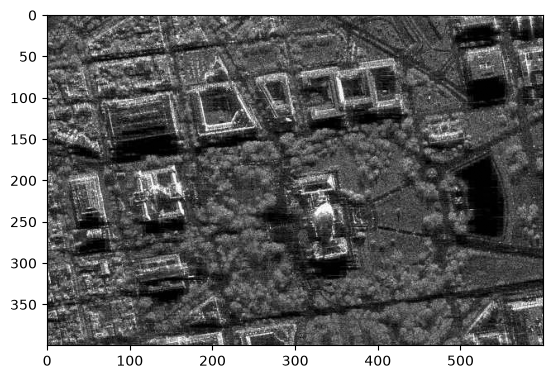

In [116]:
plt.imshow(image_gray, cmap="gray")

In [117]:
_,thresh1 = cv2.threshold(image_gray,100,255,cv2.THRESH_BINARY)

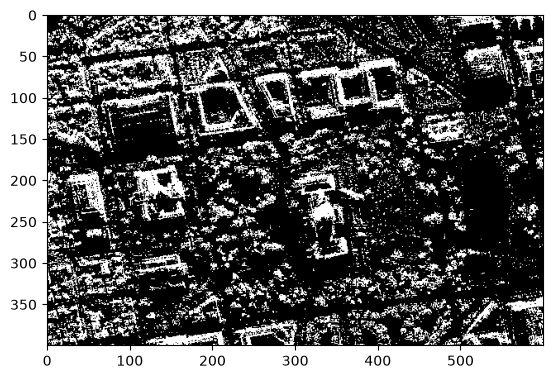

In [118]:
plt.imshow(thresh1, cmap="gray")

In [125]:
_,thresh2 = cv2.threshold(image_gray,150,255,cv2.THRESH_BINARY)

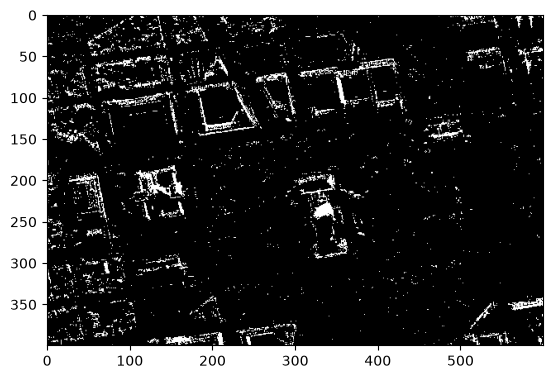

In [126]:
plt.imshow(thresh2, cmap="gray")

In [130]:
adaptive_thresh = cv2.adaptiveThreshold(
    image_gray, 
    maxValue=255, 
    adaptiveMethod=cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    thresholdType=cv2.THRESH_BINARY,
    blockSize=11,
    C=2
)

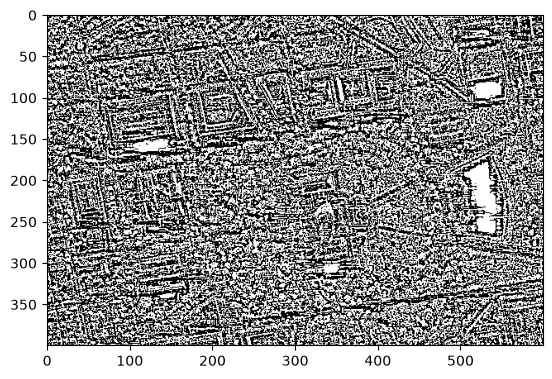

In [132]:
plt.imshow(adaptive_thresh, cmap="gray")

In [135]:
ret, thresh_otsu = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

In [138]:
print(f"Threshold: {ret}")

Threshold: 85.0


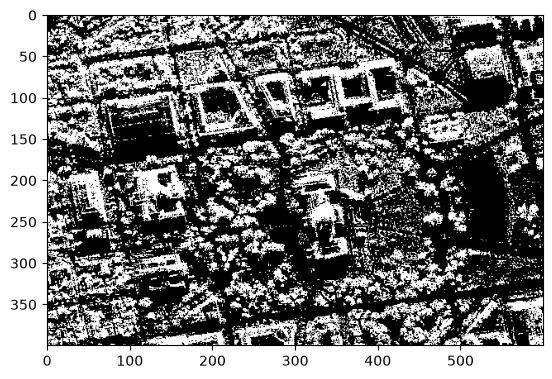

In [139]:
plt.imshow(thresh_otsu, cmap="gray")